# Retail Data Wrangling and Analytics

In [1]:
# Import modules 
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#install psql "driver"
!pip3 install psycopg2-binary


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


# Load CSV into Dataframe
The LGS IT team have recorded the transactional data into a [CSV file](https://raw.githubusercontent.com/jarviscanada/jarvis_data_eng_demo/feature/data/python_data_wrangling/data/online_retail_II.csv). However, the CSV header (column names) doesn't follow the snakecase or camelcase naming convention (e.g. `Customer ID` instead of `customer_id` or `CustomerID`). As a result, you will need to use Pandas to clean up the data before doing any analytics. In addition, unlike the PSQL scheme, CSV files do not have data types associated. Therefore, you will need to cast/convert certain columns into correct data types (e.g. DateTime, numbers, etc..)

**Data Preperation**

- Read the `data/online_retail_II.csv` file into a DataFrame
- Rename all columns to upper camelcase or snakecase
- Convert/cast all columns to the appropriate data types (e.g. datetime)

In [3]:
retail_df = pd.read_csv('data/online_retail_II.csv')
retail_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
# convert column names into snakecase
retail_df.rename(columns={"Invoice":"invoice_no", "StockCode":"stock_code", "Description":"description", "Quantity":"quantity", "InvoiceDate":"invoice_date", "Price":"unit_price", "Customer ID":"customer_id", "Country":"country"}, inplace=True)
retail_df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
# check current data types
retail_df.dtypes

invoice_no          str
stock_code          str
description         str
quantity          int64
invoice_date        str
unit_price      float64
customer_id     float64
country             str
dtype: object

In [6]:
# cast invoice_date and customer_id into appropriate types
retail_df['customer_id'] = retail_df['customer_id'].astype('Int64')
retail_df['invoice_date'] = pd.to_datetime(retail_df['invoice_date'])
retail_df.dtypes

invoice_no                 str
stock_code                 str
description                str
quantity                 int64
invoice_date    datetime64[us]
unit_price             float64
customer_id              Int64
country                    str
dtype: object

In [7]:
retail_df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


# Total Invoice Amount Distribution

In [8]:
# calculate invoice amount
retail_df['line_price'] = retail_df['unit_price'] * retail_df['quantity']
inv_amt = retail_df.groupby('invoice_no')['line_price'].sum()

In [9]:
# display the stats
inv_amt.describe()

count     53628.000000
mean        359.648888
std        1654.829288
min     -168469.600000
25%           0.000000
50%         196.345000
75%         403.652500
max      168469.600000
Name: line_price, dtype: float64

Minimum:-168469.60
Mean:359.65
Median:196.34
Mode:0.00
Maximum:168469.60



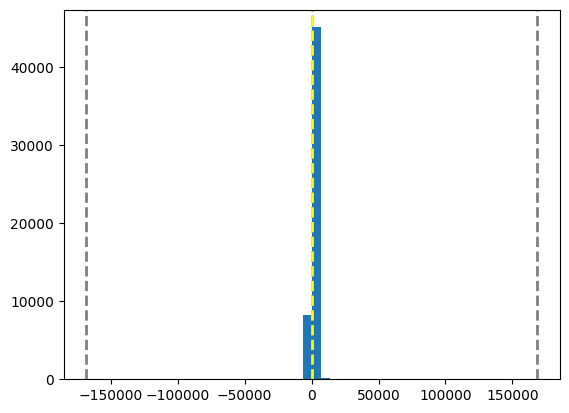

In [10]:
# get the stats
min_val = inv_amt.min()
max_val = inv_amt.max()
mean_val = inv_amt.mean()
median_val = inv_amt.median()
mode_val = inv_amt.mode()[0]

print('Minimum:{:.2f}\nMean:{:.2f}\nMedian:{:.2f}\nMode:{:.2f}\nMaximum:{:.2f}\n'.format(min_val,
                                                                                        mean_val,
                                                                                        median_val,
                                                                                        mode_val,
                                                                                        max_val))

# plot histogram
plt.hist(inv_amt, bins = 50)

plt.axvline(x=min_val, color = 'gray', linestyle='dashed', linewidth = 2)
plt.axvline(x=mean_val, color = 'cyan', linestyle='dashed', linewidth = 2)
plt.axvline(x=median_val, color = 'red', linestyle='dashed', linewidth = 2)
plt.axvline(x=mode_val, color = 'yellow', linestyle='dashed', linewidth = 2)
plt.axvline(x=max_val, color = 'gray', linestyle='dashed', linewidth = 2)
plt.show()

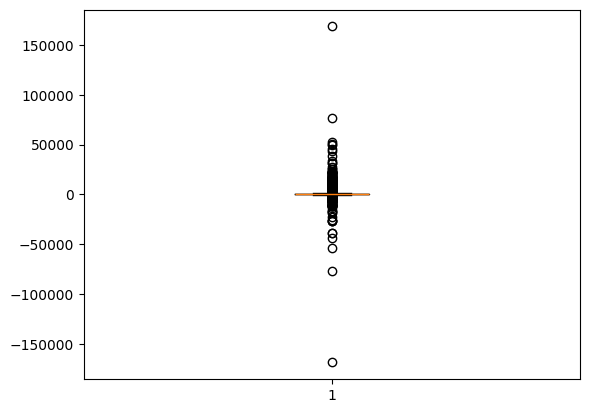

In [11]:
plt.boxplot(inv_amt)
plt.show()

In [12]:
# filter out the first 85 quantile and negatives to remove outliers
cutoff = inv_amt.quantile(0.85)
inv_amt_85 = inv_amt[(inv_amt <= cutoff) & (inv_amt > 0)]

Minimum:0.19
Mean:247.54
Median:238.90
Mode:15.00
Maximum:594.00



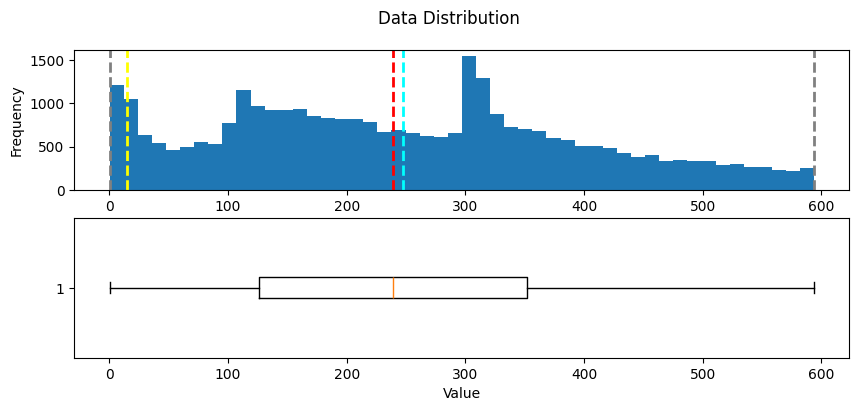

In [13]:
# redraw the plot
def show_distribution(inv_amt_85):
    min_val = inv_amt_85.min()
    max_val = inv_amt_85.max()
    mean_val = inv_amt_85.mean()
    median_val = inv_amt_85.median()
    mode_val = inv_amt_85.mode()[0]
    
    print('Minimum:{:.2f}\nMean:{:.2f}\nMedian:{:.2f}\nMode:{:.2f}\nMaximum:{:.2f}\n'.format(min_val,
                                                                                            mean_val,
                                                                                            median_val,
                                                                                            mode_val,
                                                                                            max_val))
    # Create a figure for 2 subplots (2 rows, 1 column)
    fig, ax = plt.subplots(2, 1, figsize = (10,4))
    
    # plot histogram
    ax[0].hist(inv_amt_85, bins = 50)
    ax[0].set_ylabel('Frequency')
    
    ax[0].axvline(x=min_val, color = 'gray', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mean_val, color = 'cyan', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=median_val, color = 'red', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mode_val, color = 'yellow', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=max_val, color = 'gray', linestyle='dashed', linewidth = 2)
    
    # Plot the boxplot   
    ax[1].boxplot(inv_amt_85, vert=False)
    ax[1].set_xlabel('Value')
    
    fig.suptitle('Data Distribution')
    
    plt.show()
    
show_distribution(inv_amt_85)
    

# Monthly Placed and Canceled Orders

In [14]:
# reformat invoice date in new column for easier group by
retail_df['inv_yr_month'] = retail_df['invoice_date'].dt.strftime('%Y%m').astype(int)
retail_df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,line_price,inv_yr_month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,200912
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,200912
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,200912
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,200912
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,200912


In [15]:
# total order by month
ttl_order = retail_df.groupby('inv_yr_month')['invoice_no'].nunique()

# cancelled orders per month
cncl_df = retail_df[retail_df['invoice_no'].str.startswith('C', na = False)]
cncl_order = cncl_df.groupby('inv_yr_month')['invoice_no'].nunique()

# placed orders per month
plcd_order = ttl_order - 2*cncl_order

In [16]:
# combine into a summary report
monthly_stat = pd.DataFrame({'placed orders': plcd_order, 
                             'cancelled orders':cncl_order}).fillna(0)
print(monthly_stat)

              placed orders  cancelled orders
inv_yr_month                                 
200912                 1528               401
201001                 1033               300
201002                 1489               240
201003                 1553               407
201004                 1284               304
201005                 1604               407
201006                 1502               357
201007                 1329               344
201008                 1331               273
201009                 1633               371
201010                 2013               476
201011                 2517               576
201012                 1373               326
201101                  956               260
201102                  955               219
201103                 1347               318
201104                 1264               240
201105                 1534               314
201106                 1354               329
201107                 1387       

# Monthly Sales

In [17]:
month_sales = retail_df.groupby('inv_yr_month')['line_price'].sum()

# convert to df, set indexes to column for plotting
sales_df = pd.DataFrame(month_sales).reset_index()
sales_df.head()

,inv_yr_month,line_price
0,200912,799847.110
1,201001,624032.892
2,201002,533091.426
3,201003,765848.761
4,201004,590580.432


<function matplotlib.pyplot.show(close=None, block=None)>

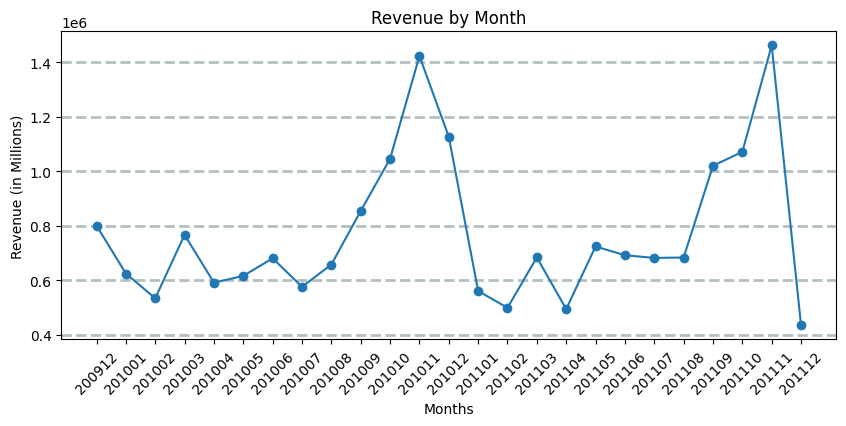

In [38]:
fig = plt.figure(figsize=(10,4))

# cast months to string instead of int to eliminate gaps in plot
plt.plot(sales_df.inv_yr_month.astype(str), sales_df.line_price, marker='o')

plt.title('Revenue by Month')
plt.xlabel('Months')
plt.ylabel('Revenue (in Millions)')
plt.grid(color='#95a5a6', linestyle='--', linewidth=2, axis='y', alpha=0.7)
plt.xticks(rotation=45)

plt.show

# Monthly Sales Growth


In [39]:
# calculate percentage change
growth = month_sales.pct_change() * 100

# convert to df, set indexes to column for plotting, rename column
growth_df = pd.DataFrame(growth).reset_index().rename(columns={'line_price': 'pct_growth'})

# fill first month's grow with 0
growth_df = growth_df.fillna(0)

growth_df

,inv_yr_month,pct_growth
0,200912,0.000000
1,201001,-21.980978
2,201002,-14.573185
3,201003,43.661804
4,201004,-22.885501
5,201005,4.189505
6,201006,10.476416
7,201007,-15.379863
8,201008,14.175039
9,201009,29.975820


<function matplotlib.pyplot.show(close=None, block=None)>

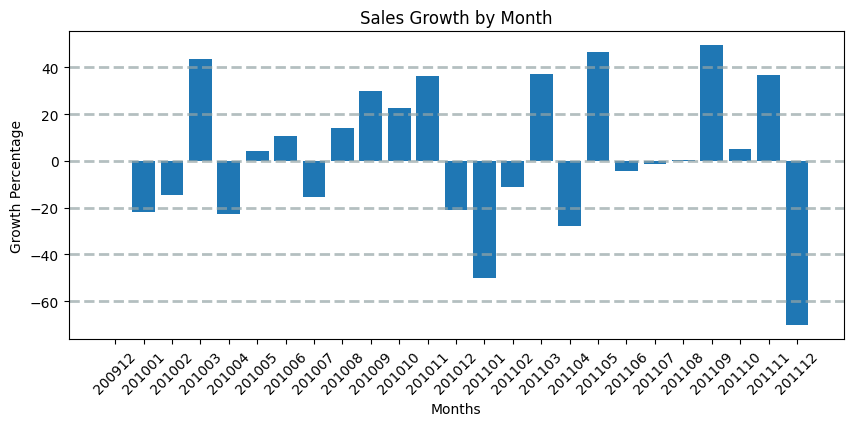

In [20]:
fig = plt.figure(figsize=(10,4))

# cast months to string instead of int to eliminate gaps in plot
plt.bar(x = growth_df.inv_yr_month.astype(str), height = growth_df.pct_growth)

plt.title('Sales Growth by Month')
plt.xlabel('Months')
plt.ylabel('Growth Percentage')
plt.grid(color='#95a5a6', linestyle='--', linewidth=2, axis='y', alpha=0.7)
plt.xticks(rotation=45)

plt.show

# Monthly Active Users

In [21]:
active = retail_df.groupby('inv_yr_month')['customer_id'].nunique()
active_df = pd.DataFrame(active).reset_index().rename(columns={'customer_id': 'active_users'})
active_df.head()

,inv_yr_month,active_users
0,200912,1045
1,201001,786
2,201002,807
3,201003,1111
4,201004,998


<function matplotlib.pyplot.show(close=None, block=None)>

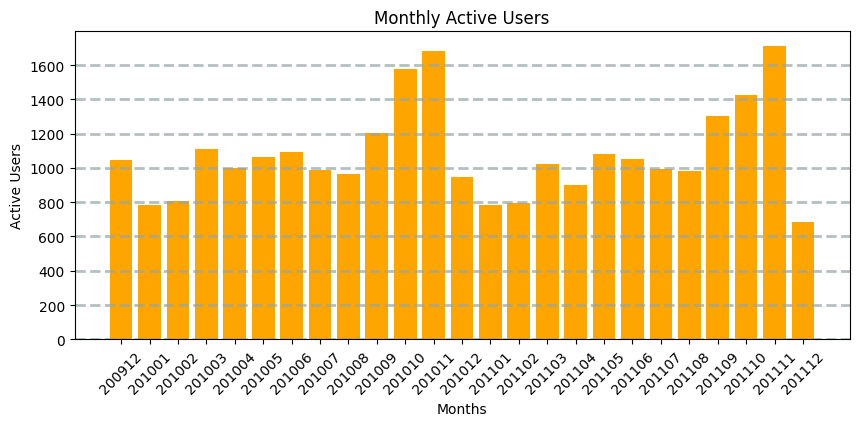

In [22]:
fig = plt.figure(figsize=(10,4))

# cast months to string instead of int to eliminate gaps in plot
plt.bar(x = active_df.inv_yr_month.astype(str), height = active_df.active_users, color = 'orange')

plt.title('Monthly Active Users')
plt.xlabel('Months')
plt.ylabel('Active Users')
plt.grid(color='#95a5a6', linestyle='--', linewidth=2, axis='y', alpha=0.7)
plt.xticks(rotation=45)

plt.show

# New and Existing Users



In [23]:
# identify month of first purchase for each customer
first_pchs = retail_df.groupby('customer_id')['inv_yr_month'].min()
first_pchs_df = pd.DataFrame(first_pchs).reset_index().rename(columns={'inv_yr_month': 'first_pchs'})
first_pchs_df.head()

,customer_id,first_pchs
0,12346,200912
1,12347,201010
2,12348,201009
3,12349,200912
4,12350,201102


In [24]:
# join the first purchase info with transactional data
txn_df = retail_df.merge(first_pchs_df, on = 'customer_id')
txn_df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,line_price,inv_yr_month,first_pchs
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,200912,200912
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,200912,200912
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,200912,200912
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,200912,200912
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,200912,200912


In [25]:
# label customer type
import numpy as np

txn_df['cust_type'] = np.where(txn_df['inv_yr_month'] == txn_df['first_pchs'], 'New', 'Existing')

In [26]:
# monthly customer count based on labelled type
new_usr = txn_df[txn_df['cust_type'] == 'New'].groupby('inv_yr_month')['customer_id'].nunique()
exst_usr = txn_df[txn_df['cust_type'] == 'Existing'].groupby('inv_yr_month')['customer_id'].nunique()

# combine into to df, fill 'nan' in the first month with 0
usrtype_df = pd.DataFrame({'New': new_usr, 'Existing': exst_usr}).reset_index().fillna(0)

In [27]:
usrtype_df.head()

,inv_yr_month,New,Existing
0,200912,1045,0.0
1,201001,394,392.0
2,201002,363,444.0
3,201003,436,675.0
4,201004,291,707.0


<function matplotlib.pyplot.show(close=None, block=None)>

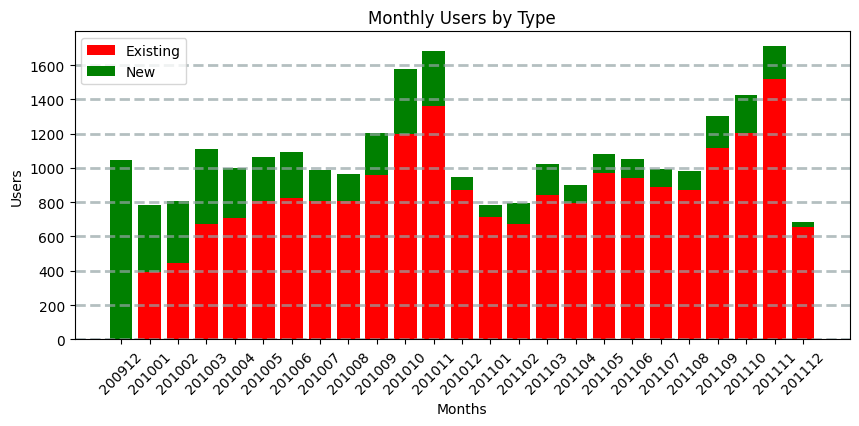

In [28]:
fig = plt.figure(figsize=(10,4))

# cast months to string instead of int to eliminate gaps in plot
plt.bar(usrtype_df['inv_yr_month'].astype(str), usrtype_df['Existing'], label='Existing', color='red')
plt.bar(usrtype_df['inv_yr_month'].astype(str), usrtype_df['New'], bottom=usrtype_df['Existing'], label='New', color='green')

plt.title('Monthly Users by Type')
plt.xlabel('Months')
plt.ylabel('Users')
plt.legend()
plt.grid(color='#95a5a6', linestyle='--', linewidth=2, axis='y', alpha=0.7)
plt.xticks(rotation=45)

plt.show

In [29]:
# we'll use the day right after the latest transaction date as "today"
tday = txn_df['invoice_date'].max() + pd.Timedelta(days=1)
print(tday)

2011-12-10 12:50:00


In [30]:
# rfm table

rfm = txn_df.groupby('customer_id').agg({
    'invoice_date': lambda x: (tday-x.max()).days, # recency = our "today" minus the most recent purchase date
    'invoice_no': 'nunique', # frequency = count of orders made
    'line_price': 'sum' # monetary value = sum of total order amount   
})

In [31]:
rfm = rfm.rename(columns={'invoice_date': 'Recency', 'invoice_no': 'Frequency', 'line_price': 'Monetary'})
rfm_df = pd.DataFrame(rfm).reset_index()
print(rfm_df)

      customer_id  Recency  Frequency  Monetary
0           12346      326         17    -64.68
1           12347        2          8   5633.32
2           12348       75          5   2019.40
3           12349       19          5   4404.54
4           12350      310          1    334.40
...           ...      ...        ...       ...
5937        18283        4         22   2736.65
5938        18284      430          2    436.68
5939        18285      661          1    427.00
5940        18286      477          3   1188.43
5941        18287       43          8   4177.89

[5942 rows x 4 columns]


# RFM Segmentation

---
**Please remove this insturction cell after you are done with coding**
RFM segmentation categorizes your customers into different segments, according to their interactions with your website, which will allow you to subsequently approach these groups in the most effective way. In this article, we will show you how to make an RFM segmentation based on an RFM score combining all three RFM parameters together and allowing you to divide your customers into 11 different segments. 

- [RFM Segmentation business cases](https://docs.exponea.com/docs/rfm-segmentation-business-use)

- [RFM Segmentation Guide](https://docs.exponea.com/docs/rfm-segmentation-business-use)

As you can see, computing RFM segmentation requires extensive domain knowledge in marketing which is out of the scope in this project. In practice, you will work with BA/DA to figure out how to compute RFM segments. To simplify this project, a [sample RFM segmentation Notebook](https://github.com/jarviscanada/jarvis_data_eng_demo/blob/feature/data/python_data_wrangling/ipynb/customer-segmentation-with-rfm-score.ipynb) is provided. You are responsible to understand everything from that Notebook and then integrate it into yours. 

- Download the [sample notebook](https://github.com/jarviscanada/jarvis_data_eng_demo/blob/feature/data/python_data_wrangling/ipynb/customer-segmentation-with-rfm-score.ipynb) and import to your Jupyter Notebook or VSCode
- Run the notebook and understand all cells
- Read the remark section at the end of the notebook. You will need this information when writing the README file
- Integrate the RFM segmentation calculation into your notebook

---

In [32]:
# rfm score values

rfm_df['Recency_score'] = pd.qcut(rfm_df['Recency'],5,labels=[5,4,3,2,1])
rfm_df['Frequancy_score'] = pd.qcut(rfm_df['Frequency'].rank(method="first"),5,labels=[1,2,3,4,5])
rfm_df['MonetaryScore'] = pd.qcut(rfm_df['Monetary'],5,labels=[1,2,3,4,5])

rfm_df.head()

,customer_id,Recency,Frequency,Monetary,Recency_score,Frequancy_score,MonetaryScore
0,12346,326,17,-64.68,2,5,1
1,12347,2,8,5633.32,5,4,5
2,12348,75,5,2019.40,3,3,4
3,12349,19,5,4404.54,4,3,5
4,12350,310,1,334.40,2,1,2


In [33]:
# fixing field names
rfm_df = rfm_df.rename(columns = {'Frequancy_score':'Frequency_score', 'MonetaryScore':'Monetary_score'})

In [34]:
# rfm score calculation
rfm_df["RFM_SCORE"] = rfm_df['Recency_score'].astype(str) + rfm_df['Frequency_score'].astype(str) + rfm_df['Monetary_score'].astype(str)

rfm_df.head()

,customer_id,Recency,Frequency,Monetary,Recency_score,Frequency_score,Monetary_score,RFM_SCORE
0,12346,326,17,-64.68,2,5,1,251
1,12347,2,8,5633.32,5,4,5,545
2,12348,75,5,2019.40,3,3,4,334
3,12349,19,5,4404.54,4,3,5,435
4,12350,310,1,334.40,2,1,2,212


In [35]:
# customer segmentation based on recency and frequency

seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Lose',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

In [36]:
# creating segment variable

rfm_df['Segment'] = rfm_df['Recency_score'].astype(str) + rfm_df['Frequency_score'].astype(str)
rfm_df['Segment'] = rfm_df['Segment'].replace(seg_map, regex=True)

rfm_df.head()

,customer_id,Recency,Frequency,Monetary,Recency_score,Frequency_score,Monetary_score,RFM_SCORE,Segment
0,12346,326,17,-64.68,2,5,1,251,Can't Lose
1,12347,2,8,5633.32,5,4,5,545,Champions
2,12348,75,5,2019.40,3,3,4,334,Need Attention
3,12349,19,5,4404.54,4,3,5,435,Potential Loyalists
4,12350,310,1,334.40,2,1,2,212,Hibernating


In [37]:
rfm_df[["Segment", "Recency","Frequency","Monetary"]].groupby("Segment").agg(["mean","count"])

Recency        Frequency            Monetary      
                           mean count       mean count          mean count
Segment                                                                   
About to Sleep       107.744125   383   1.459530   383    490.584914   383
At Risk              376.023873   754   4.668435   754   1156.046870   754
Can't Lose           320.244186    86  17.627907    86   5670.732581    86
Champions              7.857651   843  23.609727   843  10600.828796   843
Hibernating          465.668404  1535   1.336808  1535    340.030536  1535
Loyal Customers       66.962134  1162  12.017212  1162   3976.582346  1162
Need Attention       112.671533   274   3.671533   274   1097.306172   274
New Customers          9.428571    49   1.000000    49    369.995306    49
Potential Loyalists   24.922659   737   2.968792   737    901.487232   737
Promising             37.117647   119   1.000000   119    324.655798   119